### COMMON INSTRUCTIONS
Make sure to follow these instructions in order to ensure your submission is gradeable. If the automatic grading fails (check via Validate), no points are assigned!
1. Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
2. Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".
3. If you work in a group, please always work and submit in a shared server under the name of your group.
   If you work alone, then always work and submit on the server called "My Server".
4. Using Large Language Models and other AI tools is discouraged. Do not paste external code, as it can be tracked!
5. Do not upload notebooks. Always work in notebooks on the server.
6. Do not copy cells inside a notebook. Add a new cell and copy code from another cell if needed.

In [1]:
!tar czf myfiles.tar.gz ./*

---


# XAI Lecture ST 2026: Introduction to Python and Data Science

In this notebook, we will introduce basic Python concepts as well as a simple introduction to data analysis and visualization. It is meant as
1. a basic introduction/revision of python with small exercises;
2. a basic introduction/revision to data science concepts (and library usage) using a small dataset containing information about various people and their ratings of their place of residence ([sample_data.csv](./sample_data.csv)); and
3. as a playground to learn how to work with Jupyter and the `Nbgrader` workflow on this server.

Some first instructions regarding Jupyter: A notebook is structured into cells, that can either be markdown (like this one) or contain code. You can run each cell individually using the Play button in the top bar. Running a code cell means its code is executed, and any print outputs show up below the cell. Results that are assigned to variables within the code of the cell can after a run be accessed in any other cell of the notebook. Thus, one cell can build on the results of another. However, keep in mind that you need to run cells that depend on each other in the correct order.

## Installing Packages
Often you want to import packages, giving you access to more pre-defined functions. For that you must make sure these are installed for this kernel (see up right to find out what your kernel is). If you need to install new packages into your kernel, you can use the exclamation mark syntax in a code cell (this calls the command in a shell) to call python's package manager. For example, we will need the `pandas` and `matplotlib` packages for this notebook:

In [2]:
!pip install pandas

## Entering solutions for Nbgrader tests
You may have noticed that you cannot edit the cells above and including this one. This is due to the Nbgrader setup: Nbgrader defines read-only and input cells, and implement automatic validation and grading of solutions where unit tests can be defined. The following cell allows to enter code, jupyter commands, or (if it is a text cell) simply free text.

Note: The cells for providing answers are treated specially by Nbgrader. This is why downloading, modifying, and re-uploading the notebook will cause issues, because then the answer cells cannot be matched properly anymore. If you want to work offline, it is recommended to later simply copy the content of the cells.

In [3]:
# (nbgrader test)

### BEGIN SOLUTION
!pip install matplotlib
### END SOLUTION

And the following cell defines a unit test where Nbgrader can check whether your code from above successfully ran through. Note that these are set to read-only. You receive full points if the cell successfully runs through without an error.
If you would like whether your tests pass, you can check out the `Validate` button in the upper menu.

In [4]:
try:
    import matplotlib
except:
    assert False, "Seems like matplotlib was not successfully imported. Have you entered the correct jupyter command in the solution cell above?"

## Importing packages

Now back to the packages: `pandas` is used for data manipulation and analysis in tabular form, while `matplotlib` is used to create graphical representations and visualizations.

*Tip:* Like many Python packages, both have very detailed documentation with numerous examples that are worth checking out if you have any questions. See [here](https://pandas.pydata.org/docs/) and [here](https://matplotlib.org/stable/).

In [5]:
import pandas as pd ## "as pd" means that this package will be referred to as pd from here on out
import matplotlib.pyplot as plt
# this cell produces no output

## Python Basics
Here, we’ll briefly review the basics of Python. As we proceed through the course, we’ll aim to keep our programs as simple as possible and focus on the data science packages. If you’d like to learn more about Python, there are many excellent tutorials on YouTube, such as the [official tutorial](https://docs.python.org/3/tutorial/index.html) from the Python community.

(The following are playground cells that you can edit)

### Comments
Lines that begin with `#` are interpreted as comments in Python.

In [6]:
# (playground cell)

# this is a comment
print("this is no comment") # but all after the hashtag is a comment

this is no comment


### Variables and printing

In [7]:
# (playground cell)

# Variables (Type declarations are optional in Python and not required! Python automatically infers the type in the background.)
heading: str = "This is some info"
name = 'Alice'  # in python you can use both single or double quotes for strings
age: int = 25

# standard print
print("Hello world")
print(heading)

# Formatted print -> Values of variables inside a {} are inserted as strings.
print(f"Hello, my name is {name} and I am {age} years old.")
print(f"A debugging trick: {name=} and {age=} also prints the variable name.")


Hello world
This is some info
Hello, my name is Alice and I am 25 years old.
A debugging trick: name='Alice' and age=25 also prints the variable name.


### Nbgrader tests for variable values
The Nbgrader module can also test whether certain variables contain the correct value, as shown below.
To test this: Assign the name Amar to the variable `name`:

In [8]:
# (nbgrader test)

### BEGIN SOLUTION
name = 'Amar'
### END SOLUTION

In [9]:
assert name == 'Amar', "Please assign 'Amar' to the variable `name` to test Nbgrader."

### Loops

In [10]:
# (playground cell)

for i in range(5):
    print(f"This is loop iteration {i}")

This is loop iteration 0
This is loop iteration 1
This is loop iteration 2
This is loop iteration 3
This is loop iteration 4


### Functions

In [11]:
# (playground cell)

def greet(person, course = "XAI"):
    """I am a doc string and you can write here whatever you think helpful for remembering what the function should do."""
    return f"Hello {person}, welcome to the course {course}!"

greeting = greet("students")
print(greeting)

greeting = greet(course="someothercourse", person="teacher") # Python allows named arguments; when argument names are used, the order can even be swapped.
print(greeting)

Hello students, welcome to the course XAI!
Hello teacher, welcome to the course someothercourse!


### Nbgrader unit tests for functions
The usual unit tests will check whether you correctly implemented a function. As an example, implement a function called `mytest` that receives the named arguments `arg1` and `arg2` and returns `arg1`:

In [12]:
# (nbgrader test)

### BEGIN SOLUTION
def mytest(arg1, arg2):
    return arg1
### END SOLUTION

In [13]:
assert mytest(1, 2) == mytest(1, 0) == 1
assert mytest('a test', 2) == 'a test'

### Lists and Tuples

In [14]:
# (playground cell)

# 1. Creating a list
fruits = ["apple", "banana", "cherry", "date"]
print(f"The list of fruits: {fruits}")


The list of fruits: ['apple', 'banana', 'cherry', 'date']


In [15]:
# (playground cell)

# 2. Accessing Elements
# Accessing the first element (index 0)
first_fruit = fruits[0]
print(f"The first fruit in the list is: {first_fruit}")


The first fruit in the list is: apple


In [16]:
# (playground cell)

# 3. Editing Lists
# Adding an item to the end of the list
fruits.append("strawberry")
print(f"List after adding strawberry: {fruits}")

List after adding strawberry: ['apple', 'banana', 'cherry', 'date', 'strawberry']


In [17]:
# (playground cell)

# Removing a specific item
fruits.remove("banana")
print(f"List after removing Banana: {fruits}")

List after removing Banana: ['apple', 'cherry', 'date', 'strawberry']


In [18]:
# (playground cell)

# Inserting an element at a specific position
fruits.insert(1, "blueberry")
print(f"List after inserting 'Blueberry' at position 1: {fruits}")

List after inserting 'Blueberry' at position 1: ['apple', 'blueberry', 'cherry', 'date', 'strawberry']


In [19]:
# (playground cell)

# 4. Iterating over a list
print("List of all fruits:")
for fruit in fruits:
    print(fruit)

List of all fruits:
apple
blueberry
cherry
date
strawberry


In [20]:
# (playground cell)

# 5. Check if an item is in the list
if "cherry" in fruits:
    print("Cherry is in the list!")


Cherry is in the list!


In [21]:
# (playground cell)

# 6. Determine the length of the list
fruits_count = len(fruits)
print(f"The list contains {fruits_count} fruits.")

The list contains 5 fruits.


Note that strings are also handled like lists of chars.
A tuple simply is a read-only list:

In [22]:
# (playground cell)

fruits_tuple = tuple(fruits)  # creating a tuple from a list
try:
    fruits_tuple[0] = 'icecream'
except Exception as e:  # Side note: try-except blocks are how you can capture and handle errors in python.
    print(e)

# Directly creating a tuple looks similar to a list:
fruits_tuple = ("apple", "banana", "cherry", "date")
print(f"The tuple of fruits: {fruits_tuple}")

'tuple' object does not support item assignment
The tuple of fruits: ('apple', 'banana', 'cherry', 'date')


### <font color="green"> Exercises on Python basics</font>

(Playground) Create a list of strings describing your favorite food. Print the last element of the list.

In [23]:
# (playground cell)

# foods = ...

# print(...)

Implement a function `element_lengths` that receives a list of strings and returns a list containing the length of each element in the received list.

In [24]:
# (nbgrader test)

def element_lengths(inp: list[str]) -> list[int]:  # this is how one can optionally specify the function's output type
    ### BEGIN SOLUTION
    new_list = []
    for element in inp:
        new_list.append(len(element))
        
    # a more elegant solution would be to use list comprehension:
    #new_list = [len(element) for element in inp]
    
    return new_list
    ### END SOLUTION
    pass # this do-nothing operation is needed if a function is empty

In [25]:
assert tuple(element_lengths(['a', 'b'])) == (1, 1)
assert tuple(element_lengths(['abc', 'b', 'cd'])) == (3, 1, 2)

 Create a function that takes a number, multiplies it by 2, and returns the result:

In [26]:
def timesTwo(number: float) -> float:
    ### BEGIN SOLUTION
    return number * 2
    ### END SOLUTION
    pass

In [27]:
assert timesTwo(2) == 4
assert timesTwo(1234.0) == 2468.0

## Data analysis with Pandas
`pandas` is a widely used library for handling and analyzing data in tabular format. We use this here as an example for showing plotting functionalities and general data handling.

### Importing the Dataset
The following code uses the `pandas` (`pd`) package to load the dataset from the file `sample_data.csv`. Make sure the file is located in the same directory as this Jupyter Notebook. If this is not the case, you will need to adjust the path.

In [28]:
# (playground cell)

# Laden des Datensatzes: Wir erhalten ein pandas DataFrame-Objekt.
data: pd.DataFrame = pd.read_csv('./sample_data.csv') # bei Bedarf hier den Pfad auf mein/korrekter/Pfad/zu/sample_data.csv anpassen
# kein Output

### Displaying the first 5 entries in the dataset
In this section, we will display the dataset for the first time using the following command. This command displays the first 5 entries in the dataset to provide a general overview of the data:

In [29]:
# (playground cell)

data.head()

,Name,Age,City,Score
0,Alice,25,Berlin,85
1,Bob,32,Munich,67
2,Charlie,37,Berlin,90
3,David,45,Hamburg,78
4,Eve,29,Munich,95


### Display basic statistics for the dataset.
`DataFrame.describe()` displays statistics such as the mean, standard deviation, minimum, and maximum for numeric columns.

In [30]:
# (playground cell)

print("basic statistics of the dataset:")
print(data.describe())

basic statistics of the dataset:
             Age      Score
count   8.000000   8.000000
mean   34.000000  80.375000
std     6.611678  10.649447
min    25.000000  67.000000
25%    29.750000  71.000000
50%    32.500000  81.500000
75%    38.000000  88.500000
max    45.000000  95.000000


### Grouping and Analyzing Data
We group the data by city (`'City'`) and calculate the average age (`'Age'`) of each group.

In [31]:
# (playground cell)

average_age_per_city = data.groupby('City')['Age'].mean()
print(average_age_per_city)

City
Berlin     31.666667
Hamburg    37.500000
Munich     34.000000
Name: Age, dtype: float64


## Visualizing Data
In the following, we will use the `matplotlib` package to visualize our dataset.

### Creating a Bar Chart

*Note:* For ordinal categories and continuous x-values—i.e., values that have a natural order—a standard line plot can also be used (`kind='line'`).

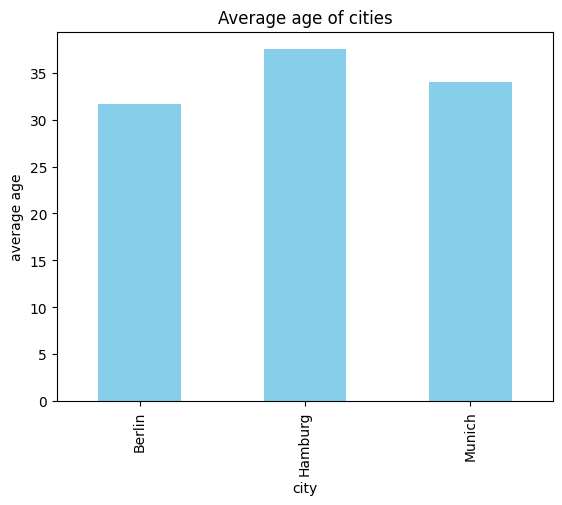

In [32]:
# (playground cell)

# title: The title of the chart
# color: The color of the bars (light blue in this case)
# ylabel: y-axis label
average_age_per_city.plot(kind='bar', color='skyblue', title='Average age of cities')
plt.ylabel('average age')
plt.xlabel('city')
plt.show()  # show the diagram

### Generating a Scatter Plot

Here, we examine whether there is a correlation between the average age of a city’s raters and its score (probably not). We also indicate whether the cities are located in southern Germany or not.

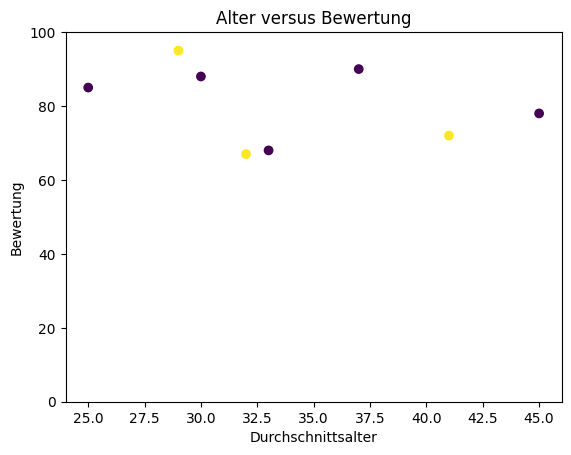

In [33]:
# (playground cell)

data['im Süden'] = (data['City'] == 'Munich') # DataFrames can be manipulated, for example, by adding new columns

plt.scatter(x=data['Age'], y=data['Score'], c=data['im Süden']) # c: color coding
plt.title('Alter versus Bewertung')
plt.ylabel('Bewertung')
plt.xlabel('Durchschnittsalter')
plt.ylim(0,100) # boundaries of coordinate system: y-Achse
plt.show() 

### Generating a Histogram

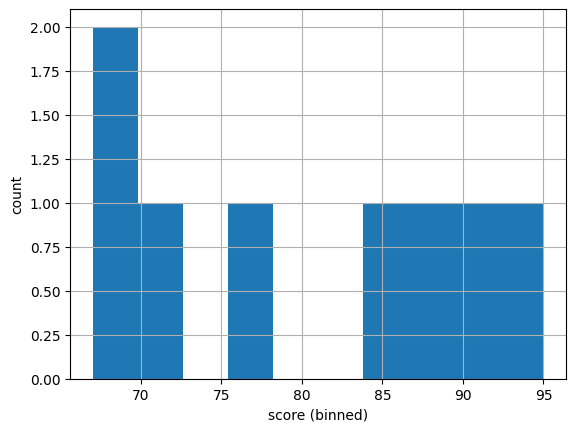

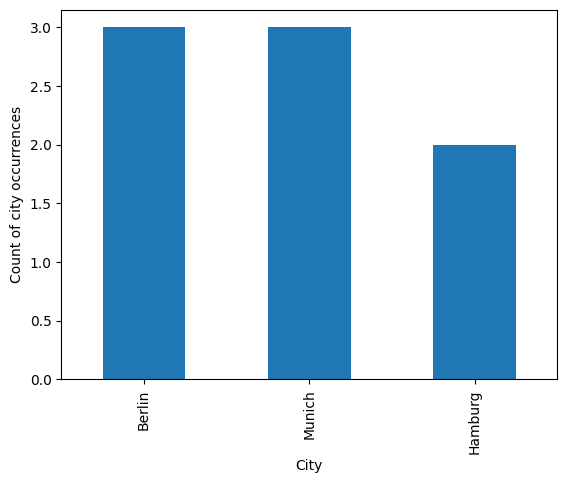

In [34]:
# (playground cell)

data['Score'].hist() # choose a column of the data via data[<columnname>]
plt.ylabel("count")
plt.xlabel("score (binned)")
plt.show()

# For categorical features, you might want to use the otherwise equivalent bar plot (just has nicer axis labels):
data['City'].value_counts().plot(kind='bar', ylabel="Count of city occurrences");

 ## <font color="green">Plotting Playground </font>

### Average Score
Above, we calculated and displayed the average age for each city. How could we do the same for the cities' scores?

In [35]:
# (playground cell)
# print(data.head())
average_age_per_city = data.groupby('City')['Age'].mean()
average_score_per_city = data.groupby('City')['Score'].mean()

# Enter the code here to calculate the average scores

print(average_score_per_city)

City
Berlin     81.0
Hamburg    83.0
Munich     78.0
Name: Score, dtype: float64


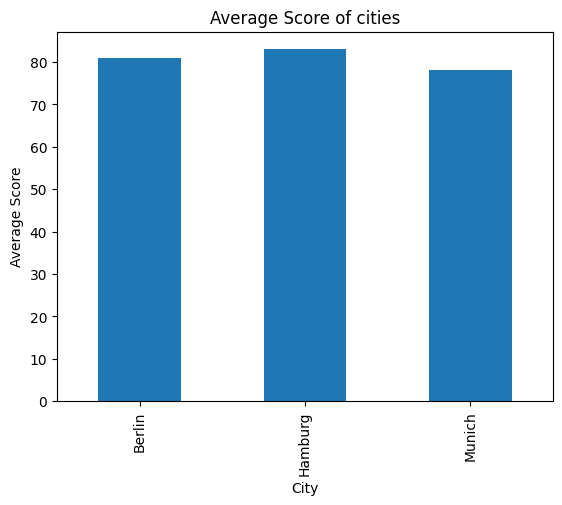

In [36]:
# (playground cell)
# Enter the code here to plot the scores
average_score_per_city.plot(kind='bar',title='Average Score of cities')
plt.ylabel("Average Score")
plt.xlabel("City")
plt.show()

### Histogram
Above, we have plotted a histogram for two of the features. Create a histogram for the age of the city's evaluators.

      Name  Age     City  Score  im Süden
0    Alice   25   Berlin     85     False
1      Bob   32   Munich     67      True
2  Charlie   37   Berlin     90     False
3    David   45  Hamburg     78     False
4      Eve   29   Munich     95      True


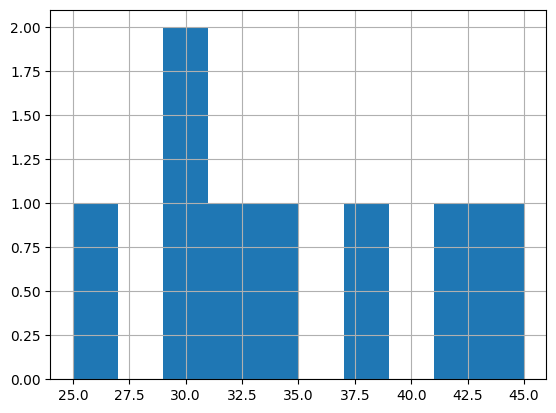

In [38]:
# (playground cell)
print(data.head())
data['Age'].hist()
# Enter the code here to plot the histogram
# data[...]...
plt.show()